In [2]:
from pathlib import Path
import os
import sys

os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

# Find repo root and add it to sys.path
_candidate_roots = [Path.cwd(), Path.cwd().parent]
for _root in _candidate_roots:
    if (_root / "pipeline").is_dir() and (_root / "config").is_dir():
        REPO_ROOT = _root
        if str(REPO_ROOT) not in sys.path:
            sys.path.insert(0, str(REPO_ROOT))
        break
else:
    raise FileNotFoundError("Could not locate repo root containing pipeline/ and config/")

print(f"Repo root: {REPO_ROOT}")


Repo root: /home/calder/code/atmo-retrieval


In [3]:
from pathlib import Path

import numpy as np
from IPython.display import Image, display

RUN_DIR = REPO_ROOT / "output/kelt20b/Duck24/transmission/2026-04-02_03-53-01"

from pipeline.diagnostics import build_diag_config_from_run_dir, build_primary_diagnostic_context
from pipeline import retrieval as _retrieval
from physics.model import compute_atmospheric_state_from_posterior
from plotting.plot import plot_transmission_spectrum

posterior = np.load(RUN_DIR / "posterior_sample.npz")
posterior_np = {k: np.asarray(posterior[k]) for k in posterior.files}

DIAG_CONFIG = build_diag_config_from_run_dir(
    RUN_DIR,
    epoch="20190504",
)

ctx = build_primary_diagnostic_context(
    **DIAG_CONFIG,
    apply_sysrem=True,
)

wav_obs_nm = np.asarray(ctx.primary_component.wav_obs) / 10.0
obs_mean, obs_err = _retrieval._summarize_observed_spectrum(
    ctx.primary_component.data,
    ctx.primary_component.sigma,
)

atmo_state_full = compute_atmospheric_state_from_posterior(
    posterior_samples=posterior_np,
    region_config=ctx.primary_region_config,
    opa_mols=ctx.primary_component.opa_mols,
    opa_atoms=ctx.primary_component.opa_atoms,
    opa_cias=ctx.primary_component.opa_cias,
    nu_grid=ctx.primary_component.nu_grid,
    use_median=True,
    sample_prefix=ctx.primary_region_sample_prefix,
)

hmc_model_ts, _ = _retrieval._compute_model_timeseries_for_plot(
    posterior_samples=posterior_np,
    model_params=ctx.model_params,
    region_config=ctx.primary_region_config,
    component=ctx.primary_component,
    region_sample_prefix=ctx.primary_region_sample_prefix,
    component_sample_prefix=ctx.primary_component_sample_prefix,
    atmo_state=atmo_state_full,
)

print("posterior keys:", posterior.files)
print("atmospheric-state keys:", list(atmo_state_full.keys()))
print("hmc_model_ts shape:", None if hmc_model_ts is None else np.asarray(hmc_model_ts).shape)


/home/calder/miniforge3/envs/retrieval/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/calder/miniforge3/envs/retrieval/lib/python3.10/site-packages/exojax/database/vald/api.py:29: FutureWarning: moldb module will be renenamed to adb in future.
  warnings.warn("moldb module will be renenamed to adb in future.", FutureWarning)
/home/calder/miniforge3/envs/retrieval/lib/python3.10/site-packages/exojax/utils/grids.py:85: UserWarning: Both input wavelength and output wavenumber are in ascending order.
  warnings.warn(
/home/calder/miniforge3/envs/retrieval/lib/python3.10/site-packages/exojax/utils/grids.py:85: UserWarning: Both input wavelength and output wavenumber are in ascending order.
  warnings.warn(
/home/calder/miniforge3/envs/retrieval/lib/python3.10/site-packages/exojax/utils/grids.py:249: U

xsmode =  premodit
xsmode assumes ESLOG in wavenumber space: xsmode=premodit
Your wavelength grid is in ***  descending  *** order
The wavenumber grid is in ascending order by definition.
Please be careful when you use the wavelength grid.
Wavenumber grid: R≈348860
integration:  simpson
Simpson integration, uses the chord optical depth at the lower boundary and midppoint of the layers.
H2-H2
H2-He
Loading HITEMP/ExoMol databases...
Loading atomic line databases (Kurucz/VALD)...
  * Fe I (cached)


/home/calder/code/atmo-retrieval/physics/model.py:299: UserWarning: 
[WARNING] Grid Under-sampling Detected!
  Instrument Resolution (R): 120000
  Physics Grid Resolution (R_grid): ~348845
  Ratio (Grid/Inst): 2.91 pixels per FWHM.
  Recommended: > 4.0 pixels per FWHM.
  Your dtau/opacity calculation might be aliased. Regenerate 'nu_grid' with higher resolution.
  warnings.warn(


posterior keys: ['Kp', 'Kp_kms', 'Mp', 'Rp', 'Rstar', 'Tirr', 'Vsys_kms', 'dRV', 'dRV_kms', 'gamma', 'kappa_ir_cgs', 'logVMR_Fe I', 'vsini_kms']
atmospheric-state keys: ['dtau', 'dtau_per_species', 'Tarr', 'pressure', 'dParr', 'mmw', 'vmrH2', 'vmrHe', 'vmr_mols', 'vmr_atoms', 'mmr_mols', 'mmr_atoms', 'params']
hmc_model_ts shape: (16, 67710)


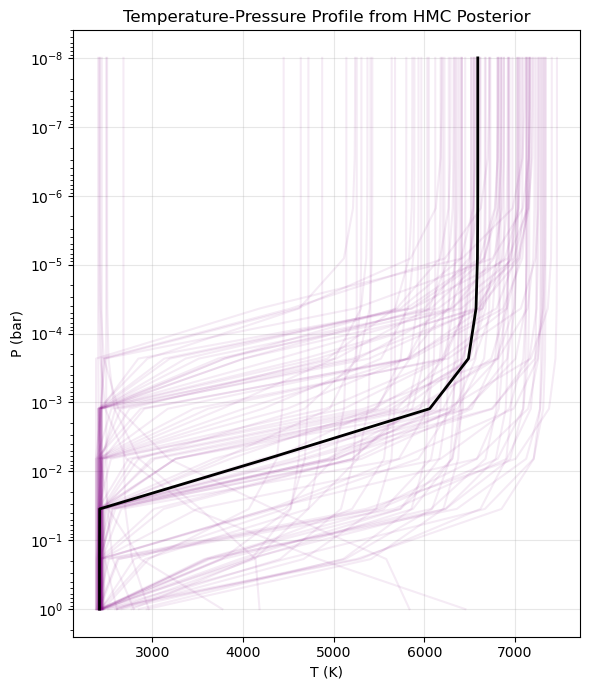

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from physics.model import reconstruct_temperature_profile

posterior = np.load(RUN_DIR / "posterior_sample.npz")
posterior_np = {k: np.asarray(posterior[k]) for k in posterior.files}

art = ctx.primary_region_config.art
pt_profile = ctx.primary_region_config.pt_profile
Tint_fixed = ctx.primary_region_config.Tint_fixed
sample_prefix = ctx.primary_region_sample_prefix

fig, ax = plt.subplots(figsize=(6, 7))

sample_sizes = [
    np.asarray(v).shape[0]
    for v in posterior_np.values()
    if np.asarray(v).ndim > 0
]
n_samples = min(sample_sizes)
draw_count = min(100, n_samples)
draw_indices = np.random.choice(n_samples, draw_count, replace=False)

for idx in draw_indices:
    sample_params = {}
    for key, values in posterior_np.items():
        arr = np.asarray(values)
        sample_params[key] = arr if arr.ndim == 0 else arr[idx]

    Tarr = reconstruct_temperature_profile(
        sample_params,
        art,
        pt_profile=pt_profile,
        Tint_fixed=Tint_fixed,
        sample_prefix=sample_prefix,
    )
    ax.plot(np.asarray(Tarr), art.pressure, color="purple", alpha=0.08)

median_params = {}
for key, values in posterior_np.items():
    arr = np.asarray(values)
    median_params[key] = arr if arr.ndim == 0 else np.median(arr, axis=0)

Tarr_median = reconstruct_temperature_profile(
    median_params,
    art,
    pt_profile=pt_profile,
    Tint_fixed=Tint_fixed,
    sample_prefix=sample_prefix,
)

ax.plot(np.asarray(Tarr_median), art.pressure, color="black", lw=2)

ax.set_xlabel("T (K)")
ax.set_ylabel("P (bar)")
ax.set_yscale("log")
ax.invert_yaxis()
ax.grid(True, alpha=0.3)
ax.set_title("Temperature-Pressure Profile from HMC Posterior")
plt.tight_layout()
plt.show()


In [ ]:
from plotting.plot import plot_transmission_spectrum

tx_path = RUN_DIR / "transmission_spectrum_hmc_recreated.png"

plot_transmission_spectrum(
    wavelength_nm=wav_obs_nm,
    rp_obs=obs_mean,
    rp_err=obs_err,
    rp_hmc=np.asarray(hmc_model_ts),
    rp_svi=np.mean(np.asarray(hmc_model_ts), axis=0),
    save_path=str(tx_path),
)

display(Image(filename=str(tx_path)))
print(f"Saved to: {tx_path}")


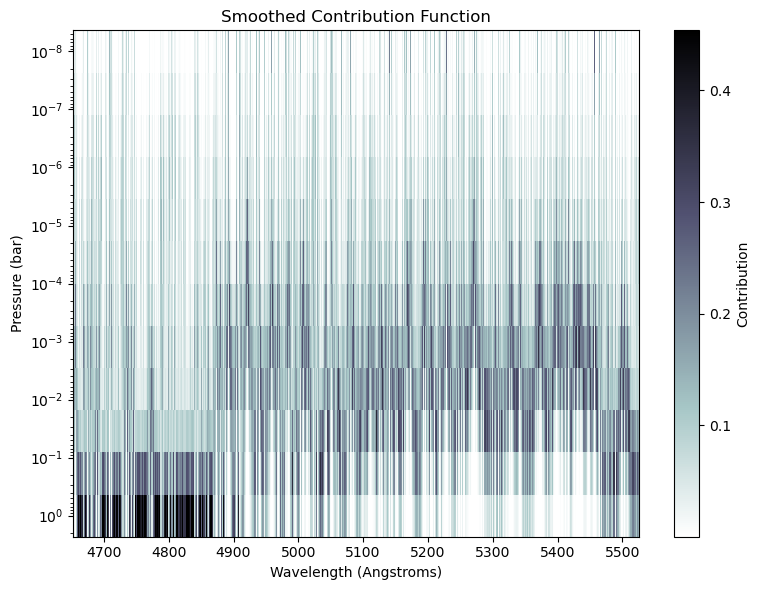

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

def linear_edges_from_centers(x):
    x = np.asarray(x)
    edges = np.empty(x.size + 1)
    edges[1:-1] = 0.5 * (x[:-1] + x[1:])
    edges[0] = x[0] - 0.5 * (x[1] - x[0])
    edges[-1] = x[-1] + 0.5 * (x[-1] - x[-2])
    return edges

def log_edges_from_centers(p):
    p = np.asarray(p)
    logp = np.log10(p)
    edges = np.empty(p.size + 1)
    edges[1:-1] = 0.5 * (logp[:-1] + logp[1:])
    edges[0] = logp[0] - 0.5 * (logp[1] - logp[0])
    edges[-1] = logp[-1] + 0.5 * (logp[-1] - logp[-2])
    return 10 ** edges

nu_grid = np.asarray(ctx.primary_component.nu_grid)
pressure = np.asarray(atmo_state_full["pressure"])
dtau = np.asarray(atmo_state_full["dtau"])

tau_cumsum = np.cumsum(dtau, axis=0)
cf = dtau * np.exp(-tau_cumsum)
cf = cf / np.where(cf.sum(axis=0, keepdims=True) > 0, cf.sum(axis=0, keepdims=True), 1.0)

wave = 1e8 / nu_grid
if wave[0] > wave[-1]:
    wave = wave[::-1]
    cf = cf[:, ::-1]

# Smooth to get the softer "paper figure" look
cf_smooth = gaussian_filter(cf, sigma=(1.0, 12.0))

# Clip dynamic range so a few line cores do not dominate
vmin = np.percentile(cf_smooth, 5)
vmax = np.percentile(cf_smooth, 99.5)
cf_plot = np.clip(cf_smooth, vmin, vmax)

wave_edges = linear_edges_from_centers(wave)
pressure_edges = log_edges_from_centers(pressure)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.pcolormesh(
    wave_edges,
    pressure_edges,
    cf_plot,
    shading="flat",
    cmap="bone_r",   # try "Blues", "BuPu", "bone_r", "PuBuGn"
)

ax.set_yscale("log")
ax.invert_yaxis()
ax.set_xlabel("Wavelength (Angstroms)")
ax.set_ylabel("Pressure (bar)")
ax.set_title("Smoothed Contribution Function")
plt.colorbar(im, ax=ax, label="Contribution")
plt.tight_layout()
plt.show()


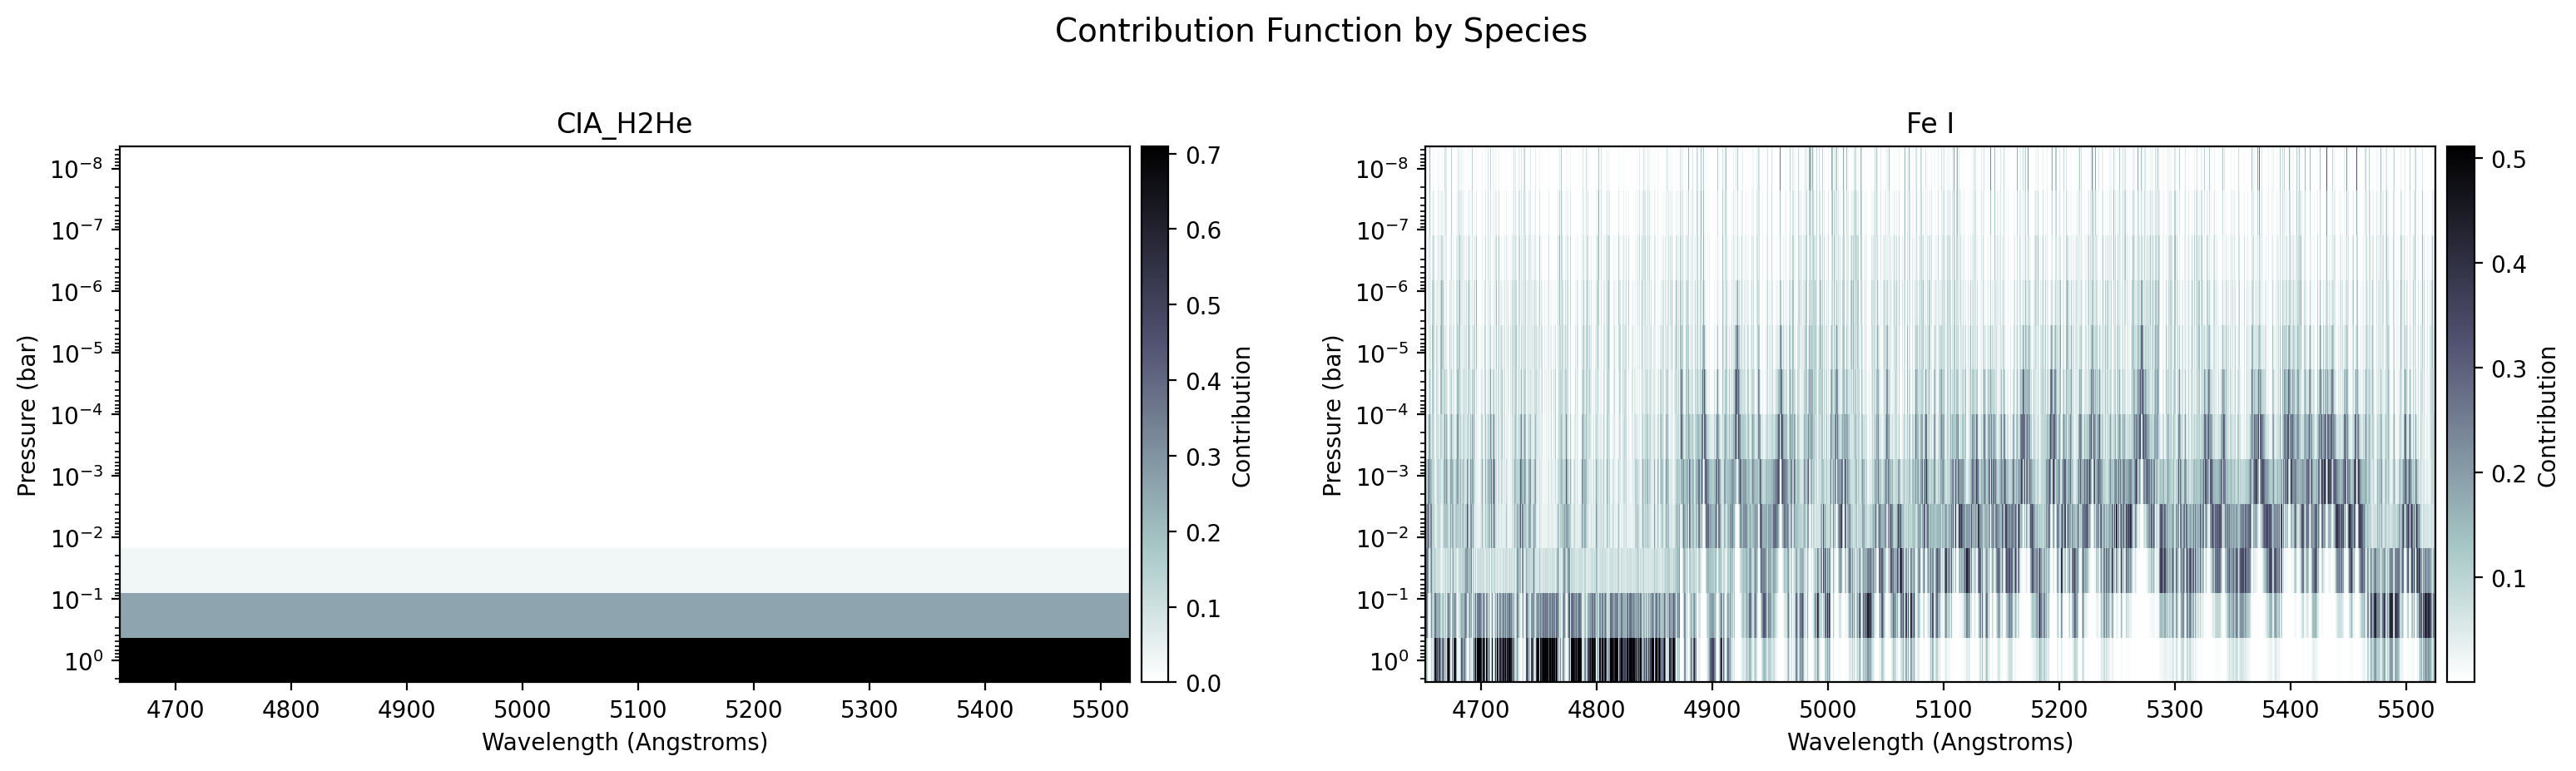

species: ['CIA_H2He', 'Fe I']
Saved to: /home/calder/code/atmo-retrieval/output/kelt20b/Duck24/transmission/2026-04-02_03-53-01/contribution_per_species_hmc_recreated.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from IPython.display import Image, display

def linear_edges_from_centers(x):
    x = np.asarray(x)
    edges = np.empty(x.size + 1)
    edges[1:-1] = 0.5 * (x[:-1] + x[1:])
    edges[0] = x[0] - 0.5 * (x[1] - x[0])
    edges[-1] = x[-1] + 0.5 * (x[-1] - x[-2])
    return edges

def log_edges_from_centers(p):
    p = np.asarray(p)
    logp = np.log10(p)
    edges = np.empty(p.size + 1)
    edges[1:-1] = 0.5 * (logp[:-1] + logp[1:])
    edges[0] = logp[0] - 0.5 * (logp[1] - logp[0])
    edges[-1] = logp[-1] + 0.5 * (logp[-1] - logp[-2])
    return 10 ** edges

def compute_contribution(dtau):
    tau_cumsum = np.cumsum(dtau, axis=0)
    cf = dtau * np.exp(-tau_cumsum)
    cf_sum = np.sum(cf, axis=0, keepdims=True)
    return cf / np.where(cf_sum > 0, cf_sum, 1.0)

per_species_path = RUN_DIR / "contribution_per_species_hmc_recreated.png"

# styling controls
SMOOTH_SIGMA = (0.8, 10.0)   # (pressure, wavelength)
CLIP_PERCENTILES = (5, 99.5)
CMAP = "bone_r"
NCOLS = 2

nu_grid = np.asarray(ctx.primary_component.nu_grid)
pressure = np.asarray(atmo_state_full["pressure"])
wave = 1e8 / nu_grid

dtau_per_species = {
    key: np.asarray(val)
    for key, val in atmo_state_full["dtau_per_species"].items()
}

if wave[0] > wave[-1]:
    wave = wave[::-1]
    dtau_per_species = {
        key: val[:, ::-1]
        for key, val in dtau_per_species.items()
    }

wave_edges = linear_edges_from_centers(wave)
pressure_edges = log_edges_from_centers(pressure)

species = list(dtau_per_species.keys())
n_species = len(species)
nrows = (n_species + NCOLS - 1) // NCOLS

fig, axes = plt.subplots(
    nrows, NCOLS,
    figsize=(8 * NCOLS, 4.5 * nrows),
    squeeze=False,
)

cf_dict = {}

for ax, sp in zip(axes.flat, species):
    cf = compute_contribution(dtau_per_species[sp])
    cf_dict[sp] = cf

    cf_plot = gaussian_filter(cf, sigma=SMOOTH_SIGMA)
    lo, hi = np.percentile(cf_plot, CLIP_PERCENTILES)
    cf_plot = np.clip(cf_plot, lo, hi)

    im = ax.pcolormesh(
        wave_edges,
        pressure_edges,
        cf_plot,
        shading="flat",
        cmap=CMAP,
    )

    ax.set_yscale("log")
    ax.invert_yaxis()
    ax.set_xlabel("Wavelength (Angstroms)")
    ax.set_ylabel("Pressure (bar)")
    ax.set_title(sp)
    plt.colorbar(im, ax=ax, pad=0.01, label="Contribution")

for ax in axes.flat[n_species:]:
    ax.set_visible(False)

fig.suptitle("Contribution Function by Species", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(per_species_path, dpi=200, bbox_inches="tight")
plt.close(fig)

display(Image(filename=str(per_species_path)))
print("species:", species)
print(f"Saved to: {per_species_path}")


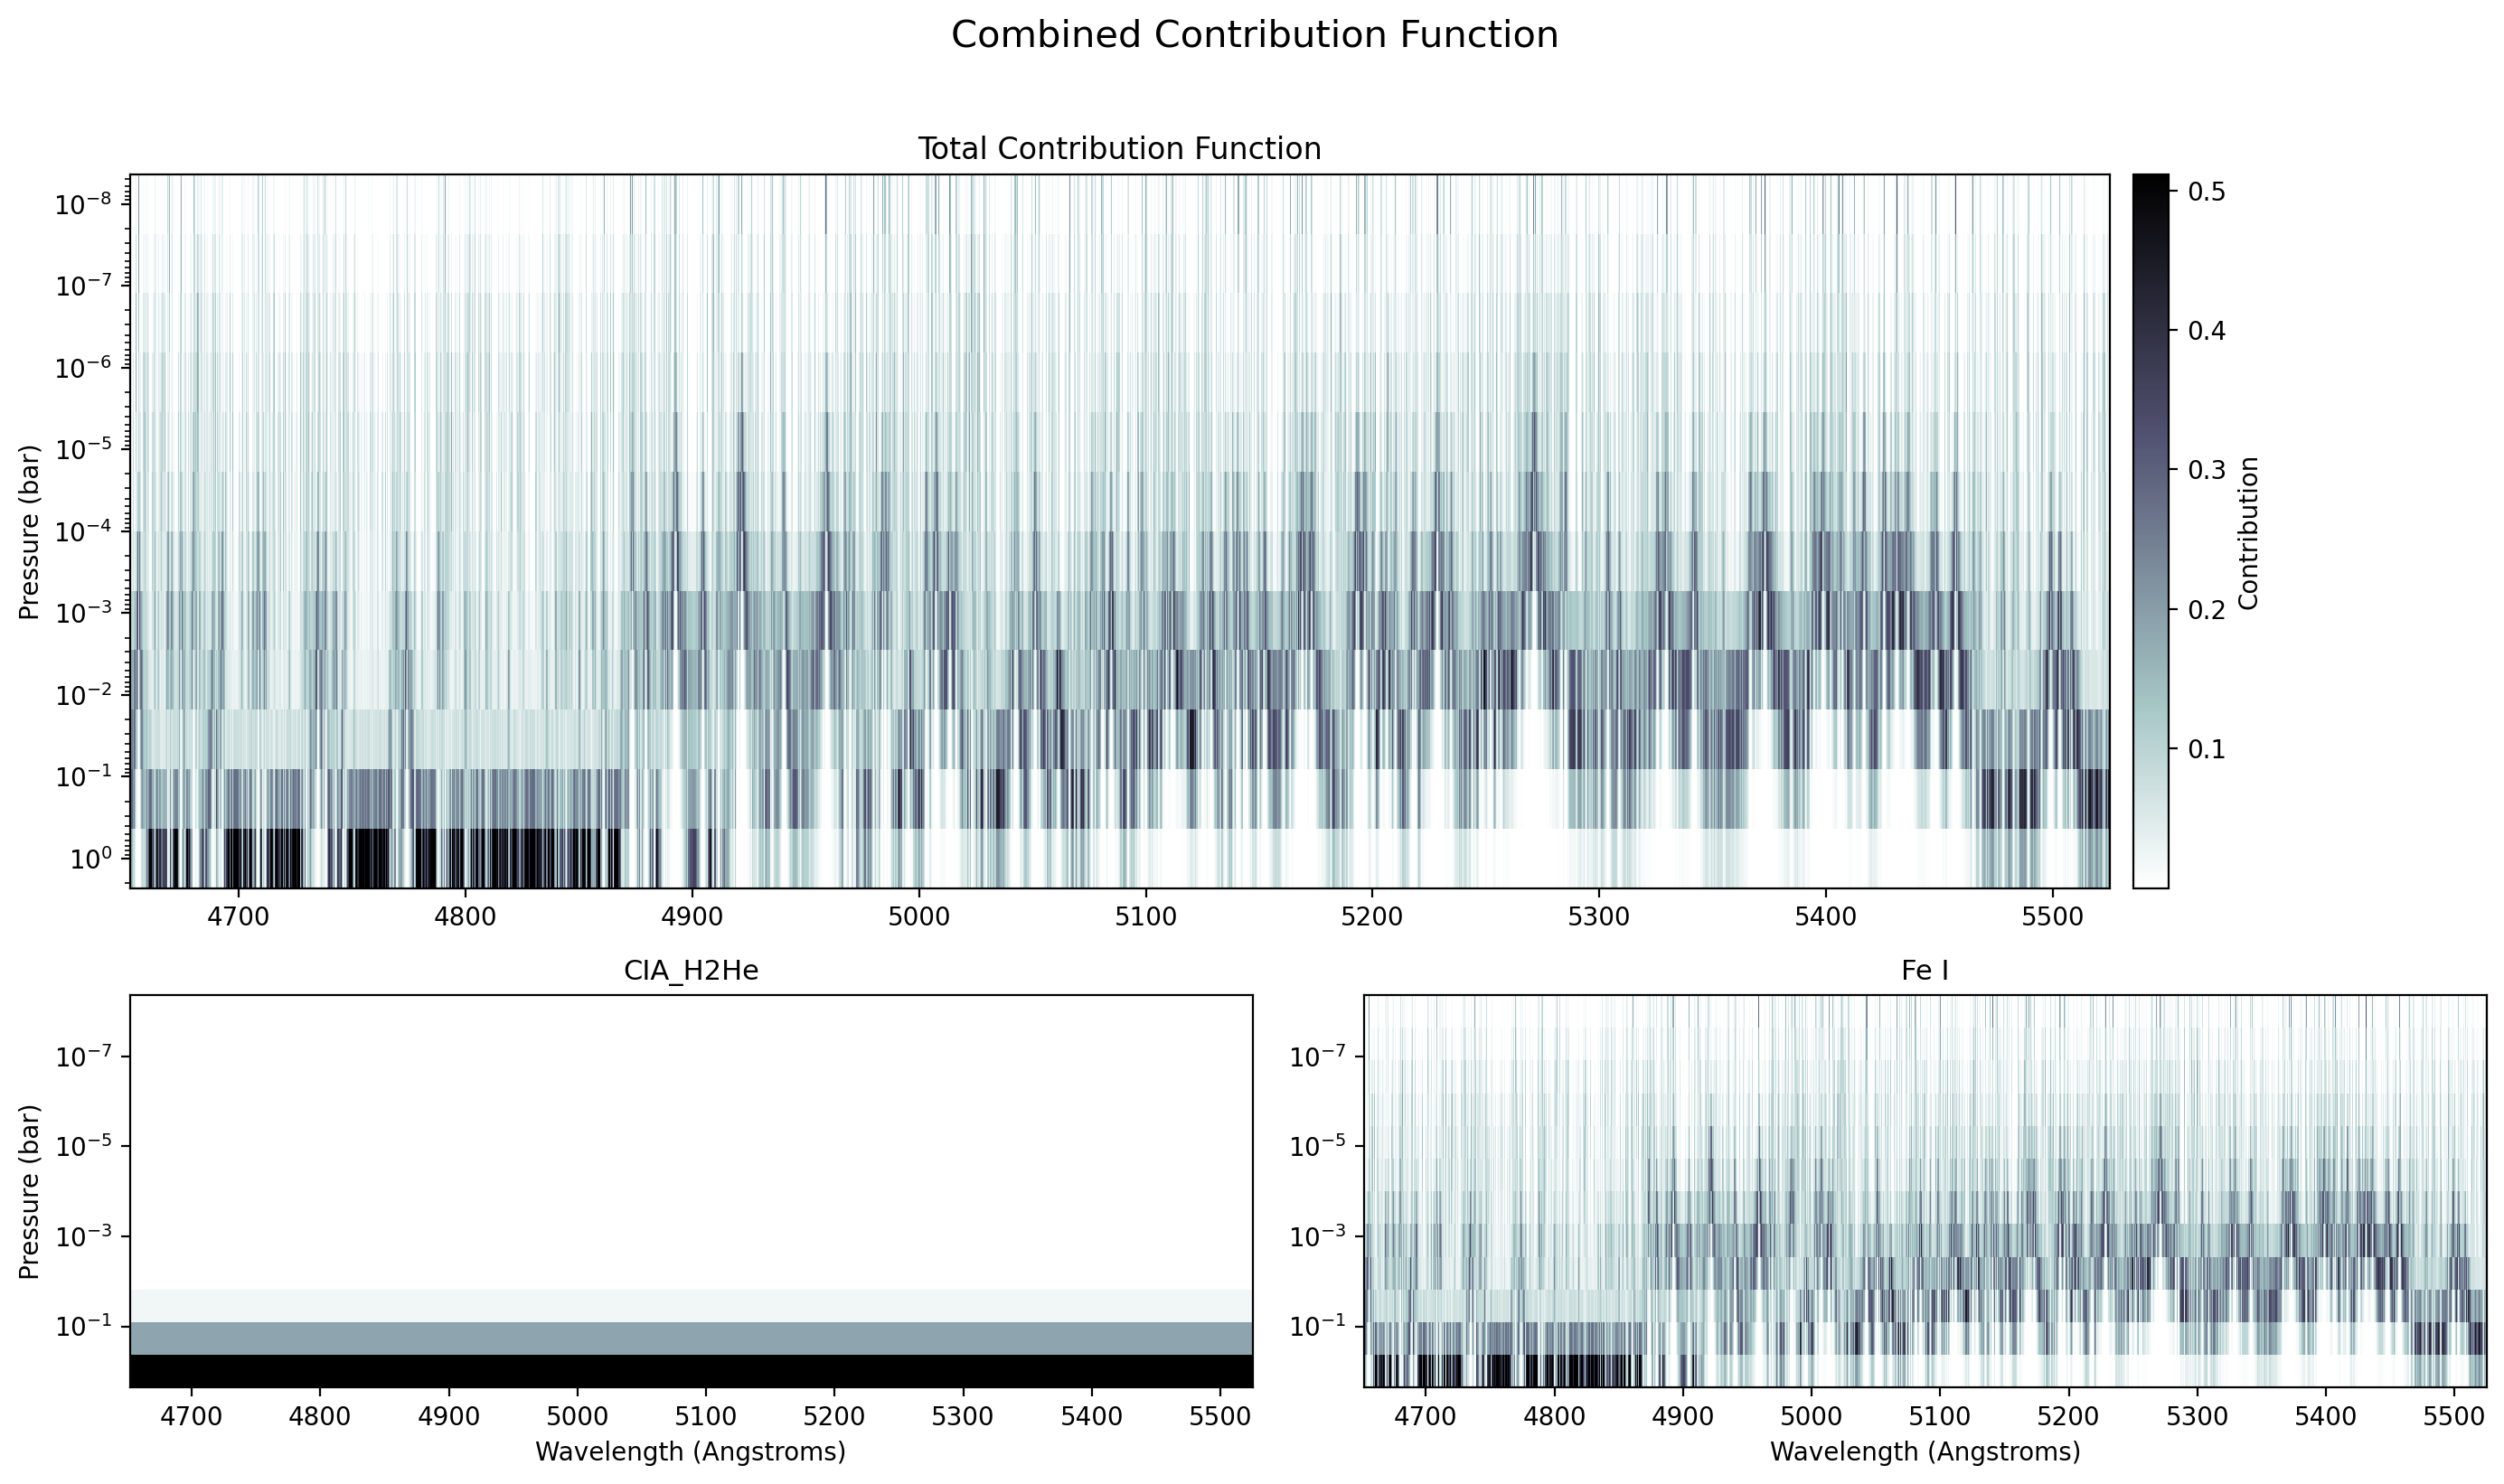

Saved to: /home/calder/code/atmo-retrieval/output/kelt20b/Duck24/transmission/2026-04-02_03-53-01/contribution_combined_hmc_recreated.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from IPython.display import Image, display

def linear_edges_from_centers(x):
    x = np.asarray(x)
    edges = np.empty(x.size + 1)
    edges[1:-1] = 0.5 * (x[:-1] + x[1:])
    edges[0] = x[0] - 0.5 * (x[1] - x[0])
    edges[-1] = x[-1] + 0.5 * (x[-1] - x[-2])
    return edges

def log_edges_from_centers(p):
    p = np.asarray(p)
    logp = np.log10(p)
    edges = np.empty(p.size + 1)
    edges[1:-1] = 0.5 * (logp[:-1] + logp[1:])
    edges[0] = logp[0] - 0.5 * (logp[1] - logp[0])
    edges[-1] = logp[-1] + 0.5 * (logp[-1] - logp[-2])
    return 10 ** edges

def compute_contribution(dtau):
    tau_cumsum = np.cumsum(dtau, axis=0)
    cf = dtau * np.exp(-tau_cumsum)
    cf_sum = np.sum(cf, axis=0, keepdims=True)
    return cf / np.where(cf_sum > 0, cf_sum, 1.0)

combined_path = RUN_DIR / "contribution_combined_hmc_recreated.png"

# styling controls
SMOOTH_SIGMA = (0.8, 10.0)
CLIP_PERCENTILES = (5, 99.5)
CMAP = "bone_r"

nu_grid = np.asarray(ctx.primary_component.nu_grid)
pressure = np.asarray(atmo_state_full["pressure"])
wave = 1e8 / nu_grid

dtau_total = np.asarray(atmo_state_full["dtau"])
dtau_per_species = {
    k: np.asarray(v) for k, v in atmo_state_full["dtau_per_species"].items()
}

if wave[0] > wave[-1]:
    wave = wave[::-1]
    dtau_total = dtau_total[:, ::-1]
    dtau_per_species = {
        k: v[:, ::-1]
        for k, v in dtau_per_species.items()
    }

wave_edges = linear_edges_from_centers(wave)
pressure_edges = log_edges_from_centers(pressure)

species = list(dtau_per_species.keys())
n_species = len(species)

fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, max(2, n_species), height_ratios=[2.0, 1.1])

# total panel
ax_total = fig.add_subplot(gs[0, :])

cf_total = compute_contribution(dtau_total)
cf_total_plot = gaussian_filter(cf_total, sigma=SMOOTH_SIGMA)
lo, hi = np.percentile(cf_total_plot, CLIP_PERCENTILES)
cf_total_plot = np.clip(cf_total_plot, lo, hi)

im = ax_total.pcolormesh(
    wave_edges,
    pressure_edges,
    cf_total_plot,
    shading="flat",
    cmap=CMAP,
)

ax_total.set_yscale("log")
ax_total.invert_yaxis()
ax_total.set_ylabel("Pressure (bar)")
ax_total.set_title("Total Contribution Function")
plt.colorbar(im, ax=ax_total, pad=0.01, label="Contribution")

# species panels
for i, sp in enumerate(species):
    ax = fig.add_subplot(gs[1, i])

    cf = compute_contribution(dtau_per_species[sp])
    cf_plot = gaussian_filter(cf, sigma=SMOOTH_SIGMA)
    lo, hi = np.percentile(cf_plot, CLIP_PERCENTILES)
    cf_plot = np.clip(cf_plot, lo, hi)

    im_sp = ax.pcolormesh(
        wave_edges,
        pressure_edges,
        cf_plot,
        shading="flat",
        cmap=CMAP,
    )

    ax.set_yscale("log")
    ax.invert_yaxis()
    ax.set_xlabel("Wavelength (Angstroms)")
    if i == 0:
        ax.set_ylabel("Pressure (bar)")
    ax.set_title(sp, fontsize=11)

# hide unused slots if any
for j in range(n_species, max(2, n_species)):
    ax = fig.add_subplot(gs[1, j])
    ax.set_visible(False)

fig.suptitle("Combined Contribution Function", fontsize=15, y=1.02)
fig.tight_layout()
fig.savefig(combined_path, dpi=200, bbox_inches="tight")
plt.close(fig)

display(Image(filename=str(combined_path)))
print(f"Saved to: {combined_path}")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
from physics.model import planet_rv_kms

# Inputs from the saved run / setup cells
wave_obs_A = np.asarray(ctx.primary_component.wav_obs)          # Angstroms
phase = np.asarray(ctx.primary_component.phase)
data_ts = np.asarray(ctx.primary_component.data)               # processed observed timeseries
sigma_ts = np.asarray(ctx.primary_component.sigma)
model_ts = np.asarray(hmc_model_ts)                            # processed model timeseries

# Use posterior medians for the orbital shift
Kp_med = float(np.median(posterior_np["Kp"]))
Vsys_med = float(np.median(posterior_np["Vsys_kms"])) if "Vsys_kms" in posterior_np else float(ctx.model_params["RV_abs"])
dRV_med = float(np.median(posterior_np["dRV"])) if "dRV" in posterior_np else 0.0

rv_planet = np.asarray(planet_rv_kms(phase, Kp_med, Vsys_med, dRV_med))

print(f"Kp_med = {Kp_med:.3f} km/s")
print(f"Vsys_med = {Vsys_med:.3f} km/s")
print(f"dRV_med = {dRV_med:.3f} km/s")

c_kms = 299792.458

def shift_to_planet_rest_frame(wave_obs, flux_ts, sigma_ts, rv_kms, rest_wave=None):
    """
    Shift each exposure into the planet rest frame and coadd on a common grid.
    """
    wave_obs = np.asarray(wave_obs)
    flux_ts = np.asarray(flux_ts)
    sigma_ts = np.asarray(sigma_ts)
    rv_kms = np.asarray(rv_kms)

    if rest_wave is None:
        rest_wave = wave_obs.copy()

    shifted_flux = []
    shifted_w = []

    for i in range(flux_ts.shape[0]):
        doppler = np.sqrt((1.0 + rv_kms[i] / c_kms) / (1.0 - rv_kms[i] / c_kms))

        # observed lambda = rest lambda * doppler
        sample_wave = rest_wave * doppler

        flux_i = np.interp(
            sample_wave,
            wave_obs,
            flux_ts[i],
            left=np.nan,
            right=np.nan,
        )

        sigma_i = np.interp(
            sample_wave,
            wave_obs,
            sigma_ts[i],
            left=np.nan,
            right=np.nan,
        )

        w_i = 1.0 / np.square(sigma_i)
        w_i[~np.isfinite(flux_i)] = 0.0
        w_i[~np.isfinite(w_i)] = 0.0

        shifted_flux.append(flux_i)
        shifted_w.append(w_i)

    shifted_flux = np.asarray(shifted_flux)
    shifted_w = np.asarray(shifted_w)

    num = np.nansum(shifted_flux * shifted_w, axis=0)
    den = np.nansum(shifted_w, axis=0)

    coadd = np.divide(num, den, out=np.full_like(num, np.nan), where=den > 0)
    coadd_err = np.divide(1.0, np.sqrt(den), out=np.full_like(den, np.nan), where=den > 0)

    return rest_wave, shifted_flux, shifted_w, coadd, coadd_err

rest_wave_A, data_rf_ts, data_rf_w, data_rf_coadd, data_rf_err = shift_to_planet_rest_frame(
    wave_obs_A,
    data_ts,
    sigma_ts,
    rv_planet,
)

_, model_rf_ts, model_rf_w, model_rf_coadd, model_rf_err = shift_to_planet_rest_frame(
    wave_obs_A,
    model_ts,
    sigma_ts,   # use data sigma only for weighted coadd
    rv_planet,
    rest_wave=rest_wave_A,
)

# Optional light smoothing for visibility only
def box_smooth(y, n=7):
    if n <= 1:
        return y
    kernel = np.ones(n) / n
    valid = np.isfinite(y)
    y0 = np.where(valid, y, 0.0)
    w0 = np.where(valid, 1.0, 0.0)
    ys = np.convolve(y0, kernel, mode="same")
    ws = np.convolve(w0, kernel, mode="same")
    return np.divide(ys, ws, out=np.full_like(ys, np.nan), where=ws > 0)

data_rf_smooth = box_smooth(data_rf_coadd, n=11)
model_rf_smooth = box_smooth(model_rf_coadd, n=11)

restframe_path = RUN_DIR / "planet_rest_frame_coadd_hmc.png"

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, height_ratios=[2, 1])
# Top: rest-frame coadd
axes[0].plot(rest_wave_A / 10.0, data_rf_coadd, color="k", lw=0.6, alpha=0.4, label="Observed coadd (planet rest frame)")
axes[0].plot(rest_wave_A / 10.0, data_rf_smooth, color="k", lw=1.5, label="Observed coadd smoothed")
axes[0].plot(rest_wave_A / 10.0, model_rf_coadd, color="tab:red", lw=0.8, alpha=0.5, label="Model coadd (planet rest frame)")
axes[0].plot(rest_wave_A / 10.0, model_rf_smooth, color="tab:red", lw=1.8, label="Model coadd smoothed")
axes[0].axhline(0.0, color="0.5", ls="--", lw=1)
axes[0].set_ylabel("Processed residual / model units")
axes[0].set_title("Planet-Rest-Frame Coadded Processed Spectrum")
axes[0].legend()
axes[0].grid(True, alpha=0.25)

# Bottom: residual
resid = data_rf_coadd - model_rf_coadd
resid_smooth = box_smooth(resid, n=11)

axes[1].plot(rest_wave_A / 10.0, resid, color="0.3", lw=0.5, alpha=0.4, label="Observed - model")
axes[1].plot(rest_wave_A / 10.0, resid_smooth, color="tab:blue", lw=1.5, label="Residual smoothed")
axes[1].axhline(0.0, color="0.5", ls="--", lw=1)
axes[1].set_xlabel("Wavelength [nm]")
axes[1].set_ylabel("Residual")
axes[1].legend()
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
fig.savefig(restframe_path, dpi=200, bbox_inches="tight")
plt.close(fig)

display(Image(filename=str(restframe_path)))
print(f"Saved to: {restframe_path}")
